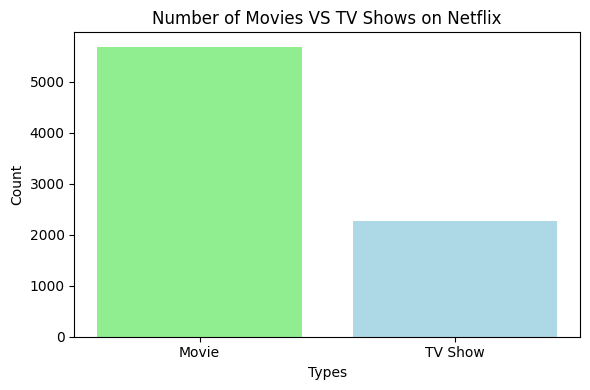

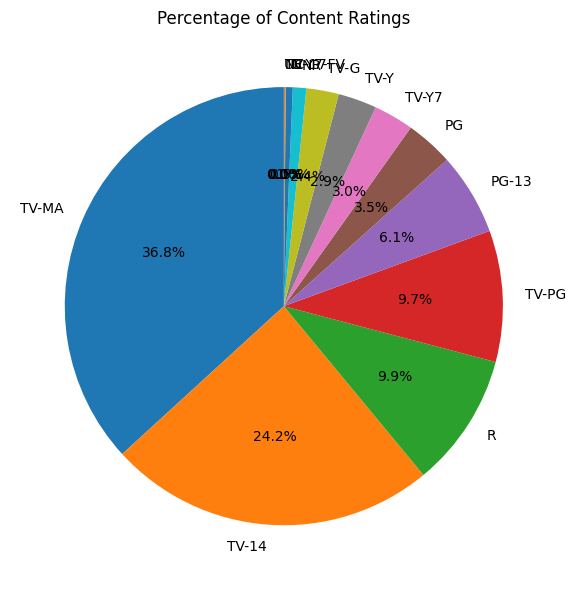

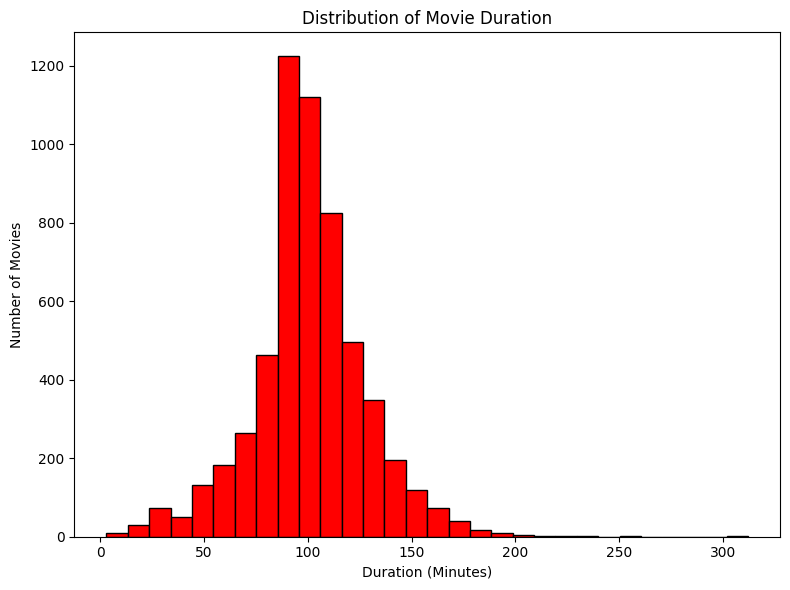

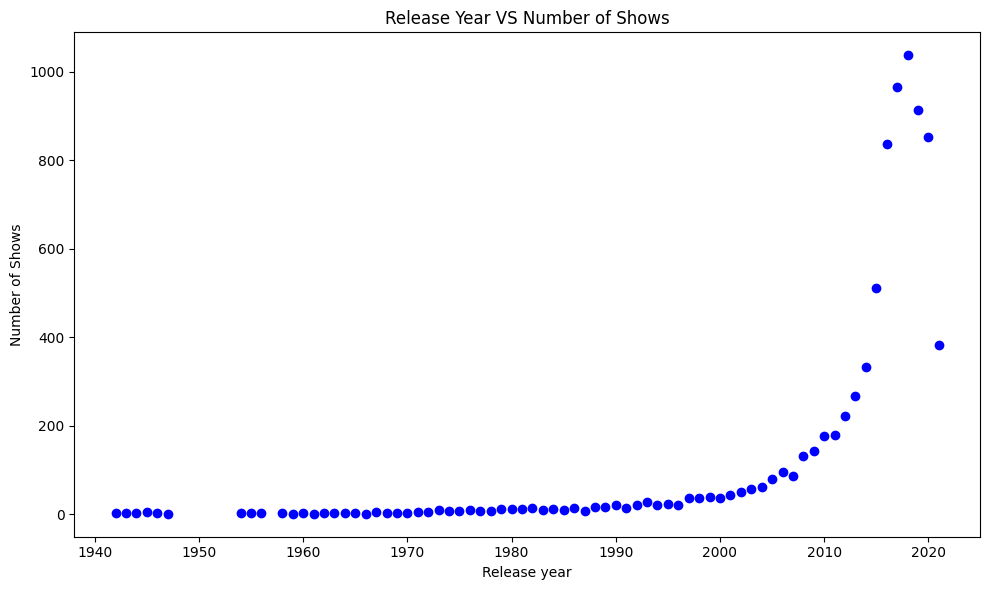

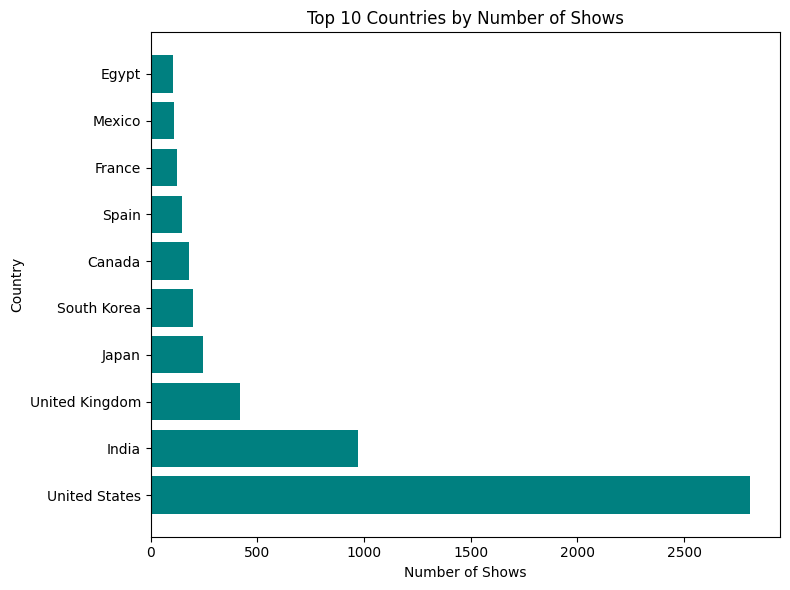

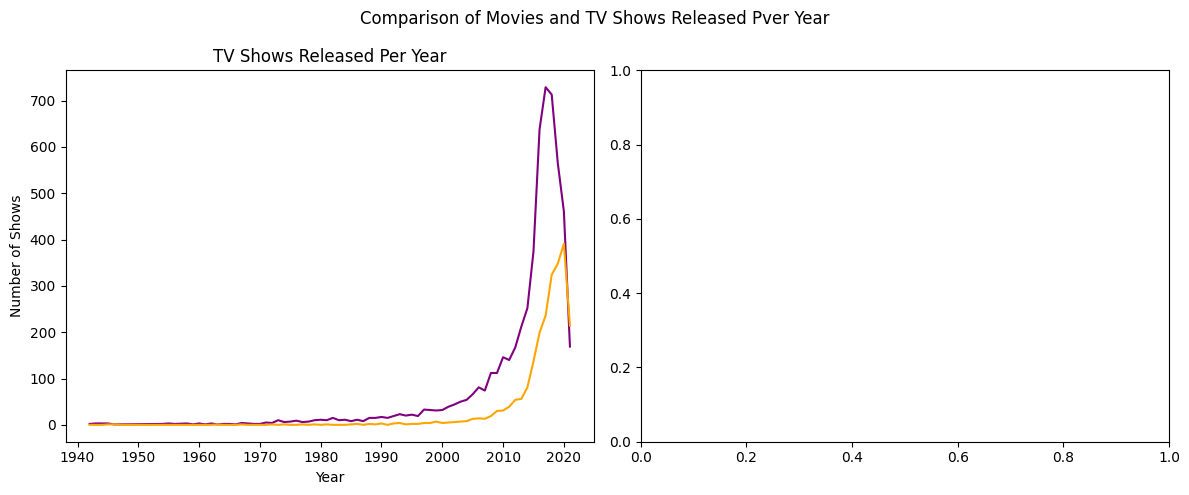

In [2]:
#step 1: Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the Data
df = pd.read_csv('netflix_titles.csv')

# Clean the Data
df = df.dropna(subset=['type','release_year','date_added', 'rating', 'country', 'duration' ])

type_count=df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_count.index, type_count.values, color=['lightGreen', 'lightBlue'])
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Types')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('Content_Ratings_pie.png')
plt.show()

movie_df= df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='red', edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_Duration_histogram.png')
plt.show()


release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='blue')
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('Release_Year_Scatter.png')
plt.show()

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top_10_countries.png')
plt.show()

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))

# first subplot:movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='purple')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

# Second subplot:TV Shows
ax[0].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[0].set_title('TV Shows Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Shows')

fig.suptitle('Comparison of Movies and TV Shows Released Over Year')
plt.tight_layout()
plt.savefig('Movies_and_TV_Shows_Comparison.png')
plt.show()